# Organização do banco de dados

In [1]:
import os
import copy
import json
import time
from pathlib import Path
#import yaml
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import sys
sys.path.append(os.path.join("..", "src"))

from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import create_sliding_windows, train_split, create_batchs
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv
                                     )    
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss

from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import eval_with_loader, train_batched_only


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "quick"  # quick or full
if RUN_MODE == "full":
    start_date = "1980-01-01"
    end_date = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date = "2025-12-31"
    
    
catalog_dir = Path(os.path.join("..", "Datasets", "dados_inmet"))
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)

In [2]:
def get_var_at_stations(ds: xr.Dataset,
                        var_name: str,
                        t1: str,
                        t2: str,
                        stations: dict) -> np.ndarray:
    """
    Extrai a variável `var_name` de um dataset ERA5 nos pontos das estações.
    Retorna array (T, N) com a série temporal diária para cada estação.
    """
    da = ds[var_name].sel(time=slice(t1, t2))                # Recorta o intervalo temporal desejado
 
    # Detecta os nomes das coordenadas espaciais (ERA5 usa latitude/longitude)
    lat_name = "latitude" if "latitude" in da.dims else "lat"   # Nome do eixo de latitude
    lon_name = "longitude" if "longitude" in da.dims else "lon" # Nome do eixo de longitude
 
    series = []                                              # Lista para acumular séries por estação
    for sid, info in stations.items():                       # Itera sobre cada estação no dicionário
        lat, lon = info["lat"], info["lon"]                  # Coordenadas da estação atual
        s = da.sel({lat_name: lat, lon_name: lon},           # Interpolação por vizinho mais próximo
                   method="nearest").values                  # Converte para NumPy
        series.append(s)                                     # Acumula a série da estação
 
    arr = np.stack(series, axis=1)                           # Empilha → shape (T, N)
 
    # Se a série é horária, agrega para diária (média do dia)
    if len(arr) > (pd.to_datetime(t2) - pd.to_datetime(t1)).days + 1:
        # Recria com índice temporal e faz resample diário
        time_index = pd.to_datetime(da["time"].values)       # Índice de tempo do xarray
        df = pd.DataFrame(arr, index=time_index)             # DataFrame para usar resample
        arr = df.resample("D").mean().values                 # Média diária por estação
 
    return arr.astype(np.float32)                            # Retorna como float32


def max_graph_aggregate(H_prev, A, include_self=True):
    if not include_self:
        A = A.clone()
        A.fill_diagonal_(0)
    
    mask = (A > 0)
    H_nodes = H_prev.transpose(1,2)  # (B, N, H)
    msgs = H_nodes.unsqueeze(2).expand(-1,-1, A.size(1), -1)
    
    msgs = msgs.masked_fill(
        ~mask.unsqueeze(0).unsqueeze(-1),
        float("-inf")
    )
    
    H_graph = msgs.amax(dim=1)
    H_graph = torch.where(torch.isfinite(H_graph), H_graph, torch.zeros_like(H_graph))
    
    return H_graph.transpose(1,2)

#### Aqui mostra a estação, escolhi o ID 32 - PORTO ALEGRE - JARDIM BOTÂNICO

In [3]:
estacoes = list(estacoes_RS.keys())
print(f"Estação no índice 32: {estacoes[32]}")
print(f"Coordenadas: {estacoes_RS[estacoes[32]]}")

Estação no índice 32: PORTO ALEGRE - JARDIM BOTANICO
Coordenadas: ['-30.05361111', '-51.17472221']


#### Carregamento do banco de dados

In [4]:
# ============================================================
# 2) CARREGAMENTO DOS DATASETS
# ============================================================
base = os.path.join("..")
nc_dir = os.path.join(base, "Datasets", "nc_files")          # Pasta com os arquivos NetCDF
 
start_date = "2024-01-01"                                    # Início do período
end_date   = "2025-12-31"                                    # Fim do período
 
# Carrega os três datasets (precipitação, temperatura, umidade/orvalho)
rea_tp = xr.open_dataset(os.path.join(nc_dir, "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))   # Precipitação
rea_temp  = xr.open_dataset(os.path.join(nc_dir, "temp_99-25.nc")).sel(time=slice(start_date, end_date))     # Temperatura 2m (t2m)
rea_vv = xr.open_dataset(os.path.join(nc_dir, "vv_94-25.nc")).sel(time=slice(start_date, end_date))        # Vertical Velocity
# Obs.: ajuste os nomes dos arquivos conforme o que você baixou do CDS.
# Se você tem RH diretamente, pode pular o cálculo de UR mais abaixo.
 
T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1   # Total de dias
N = len(estacoes_RS)                                                    # Total de estações
 
 

In [5]:
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))

In [6]:
X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_t = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)
X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

In [7]:
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors

# Itera sobre os valores e converte string -> float
coords = np.array([[float(lat), float(lon)] for lat, lon in estacoes_RS.values()],
                  dtype=np.float64)
nomes = list(estacoes_RS.keys())   # guarde se quiser saber qual nó é qual estação
N = coords.shape[0]

In [8]:
k = 2
nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
_, idx = nbrs.kneighbors(coords)
idx = idx[:, 1:]

# =====================================================
# Matriz de adjacência binária
# =====================================================

# Cria uma matriz N x N preenchida com zeros — base da matriz de adjacência.
# Tipo float32 porque será usada em multiplicações com tensores PyTorch.
A = np.zeros((N, N), dtype=np.float32)

# Para cada nó i, marca como 1 a posição dos seus k vizinhos mais próximos.
# A[i, idx[i]] = 1.0 indica "existe aresta de i para cada vizinho na lista idx[i]".
# Note: nesse passo, A ainda é direcional (i -> j não implica j -> i).
for i in range(N):
    A[i, idx[i]] = 1.0

# Torna a matriz simétrica via "OU" entre A e sua transposta.
# np.maximum(A, A.T) garante que se i é vizinho de j OU j é vizinho de i, a aresta existe nos dois sentidos.
# Isso transforma o grafo k-NN direcionado em um grafo não-direcionado (vizinhança mútua).
A = np.maximum(A, A.T)

# Adiciona self-loops (cada nó conectado a si mesmo) somando a matriz identidade.
# Self-loops fazem com que, na agregação A @ X, cada nó preserve suas próprias features
# junto com as dos vizinhos, em vez de ser substituído apenas pela média da vizinhança.
A = A + np.eye(N, dtype=np.float32)

# =====================================================
# Normalização por grau (mean aggregator): D^{-1} A
# =====================================================

# Calcula o grau de cada nó (soma das conexões na linha) — quantos vizinhos cada um tem (incluindo self-loop).
# keepdims=True mantém shape (N, 1) para permitir broadcasting na divisão linha a linha.
deg = A.sum(axis=1, keepdims=True)

# Divide cada linha de A pelo grau correspondente, transformando soma em média.
# Resultado: cada linha de A_norm soma 1 — agregação vira "média das features dos vizinhos".
# Converte para tensor PyTorch float32 para uso direto no forward da GNN (X_in @ A_norm).
A_norm = torch.tensor(A / deg, dtype=torch.float32)   # shape (N, N)

In [9]:
print(A_norm)

tensor([[0.3333, 0.0000, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1667, 0.0000,  ..., 0.0000, 0.1667, 0.0000],
        [0.2000, 0.0000, 0.2000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.3333, 0.0000, 0.0000],
        [0.0000, 0.3333, 0.0000,  ..., 0.0000, 0.3333, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.3333]])


# Modelo

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import random
from sklearn.metrics import r2_score

# =====================================================
# 0) Reprodutibilidade
# =====================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

target_date = "2024-02-08" # Data-alvo
n_idx = 32 # ID da estação (32 - Porto Alegre, Jardim Botânico)
F_in  = 2 # F_in é a dimensão das features de entrada. Como estamos tratando 
          # de umidade e velocidade vertical, a dimensão é 2.
epochs = 300 # Épocas
hidden = 256 # Número de neurônios na camada oculta
lr = 1e-2 # Taxa de aprendizado "eta".

# Proporções do split (por nós)
p_train = 0.70
p_val   = 0.15
p_test  = 0.15  # implícito: 1 - p_train - p_val

# =====================================================
# 2) Monta entrada e target para o dia alvo
# =====================================================
t_idx = (pd.to_datetime(target_date) - pd.to_datetime(start_date)).days

vv_t = X_vv[t_idx, :, 0]
t_t  = X_t [t_idx, :, 0]
X_in = torch.stack([vv_t, t_t], dim=-1).float()   # (N, 2)

y_all = X_tp[t_idx, :, 0].float()                 # (N,)

N = X_in.shape[0]   # nº total de nós

# =====================================================
# 2.1) Split por nós: treino / validação / teste
# =====================================================
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(N, generator=g)

n_train = int(round(p_train * N))
n_val   = int(round(p_val   * N))
n_test  = N - n_train - n_val

idx_train = perm[:n_train]
idx_val   = perm[n_train : n_train + n_val]
idx_test  = perm[n_train + n_val:]

def make_mask(indices, N):
    m = torch.zeros(N, dtype=torch.bool)
    m[indices] = True
    return m

mask_train = make_mask(idx_train, N)
mask_val   = make_mask(idx_val,   N)
mask_test  = make_mask(idx_test,  N)

print(f"Total de nós: {N}")
print(f"  Treino: {mask_train.sum().item()}  "
      f"Val: {mask_val.sum().item()}  "
      f"Teste: {mask_test.sum().item()}")

# =====================================================
# 3) Modelo: GNN simples de 2 camadas
# =====================================================
class SimpleGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim=1):
        super().__init__()
        self.W1 = nn.Linear(in_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, X, A_norm):
        H = A_norm @ X
        H = F.relu(self.W1(H))
        H = A_norm @ H
        out = self.W2(H)
        return out.squeeze(-1)

modelo = SimpleGNN(in_dim=F_in, hidden_dim=hidden)
otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# =====================================================
# 4) Loop de treino — loss nos nós de TREINO,
#    monitoramento nos nós de VALIDAÇÃO
# =====================================================
historico = {"train_loss": [], "val_loss": []}
training_losses = {"train_loss": [], "val_loss": [], "train_r2": [], "val_r2": []}

for epoca in range(epochs + 1):
    # ---- treino ----
    modelo.train()
    otimizador.zero_grad()

    y_pred_all = modelo(X_in, A_norm)
    loss_train = loss_fn(y_pred_all[mask_train], y_all[mask_train])
    loss_train.backward()
    otimizador.step()
    training_losses["train_loss"].append(loss_train.item())
    training_losses['train_r2'].append(r2_score(y_all[mask_train].cpu(), y_pred_all[mask_train].detach().cpu()))
    # ---- validação ----
    modelo.eval()
    with torch.no_grad():
        y_pred_eval = modelo(X_in, A_norm)
        loss_val = loss_fn(y_pred_eval[mask_val], y_all[mask_val])

    training_losses["val_loss"].append(loss_val.item())
    training_losses['val_r2'].append(r2_score(y_all[mask_val].cpu(), y_pred_eval[mask_val].detach().cpu()))
    historico["train_loss"].append(loss_train.item())
    historico["val_loss"].append(loss_val.item())

    if epoca % 10 == 0:
        print(f"Época {epoca:3d} | "
              f"Loss treino: {loss_train.item():.4f} | "
              f"Loss val: {loss_val.item():.4f}")


# =====================================================
# 5) Avaliação final no conjunto de TESTE
# =====================================================
modelo.eval()
with torch.no_grad():
    y_pred_all = modelo(X_in, A_norm)

    loss_train_f = loss_fn(y_pred_all[mask_train], y_all[mask_train]).item()
    loss_val_f   = loss_fn(y_pred_all[mask_val],   y_all[mask_val]).item()
    loss_test_f  = loss_fn(y_pred_all[mask_test],  y_all[mask_test]).item()

    mae = lambda a, b: (a - b).abs().mean().item()
    mae_train = mae(y_pred_all[mask_train], y_all[mask_train])
    mae_val   = mae(y_pred_all[mask_val],   y_all[mask_val])
    mae_test  = mae(y_pred_all[mask_test],  y_all[mask_test])

print("\n===== Resultado final =====")
print(f"Treino  -> MSE: {loss_train_f:.4f} | MAE: {mae_train:.4f}")
print(f"Val     -> MSE: {loss_val_f:.4f}  | MAE: {mae_val:.4f}")
print(f"Teste   -> MSE: {loss_test_f:.4f} | MAE: {mae_test:.4f}")

n_idx = 32  # nó de interesse

# ... dentro do bloco de avaliação final, depois de calcular y_pred_all:

# Identifica em qual conjunto o nó caiu
if mask_train[n_idx]:
    conjunto = "treino"
elif mask_val[n_idx]:
    conjunto = "validação"
else:
    conjunto = "teste"

print(f"\nNó {n_idx} (conjunto: {conjunto}):")
print(f"  Real    : {y_all[n_idx].item():.4f}")
print(f"  Predito : {y_pred_all[n_idx].item():.4f}")

Total de nós: 62
  Treino: 43  Val: 9  Teste: 10
Época   0 | Loss treino: 1.0272 | Loss val: 90.4070
Época  10 | Loss treino: 23.3084 | Loss val: 10.0103
Época  20 | Loss treino: 4.4345 | Loss val: 6.5401
Época  30 | Loss treino: 0.8383 | Loss val: 0.5129
Época  40 | Loss treino: 1.4719 | Loss val: 0.9928
Época  50 | Loss treino: 0.7707 | Loss val: 0.8587
Época  60 | Loss treino: 0.5128 | Loss val: 0.6103
Época  70 | Loss treino: 0.4739 | Loss val: 0.5217
Época  80 | Loss treino: 0.4694 | Loss val: 0.4959
Época  90 | Loss treino: 0.4687 | Loss val: 0.4863
Época 100 | Loss treino: 0.4681 | Loss val: 0.4807
Época 110 | Loss treino: 0.4669 | Loss val: 0.4766
Época 120 | Loss treino: 0.4658 | Loss val: 0.4738
Época 130 | Loss treino: 0.4650 | Loss val: 0.4725
Época 140 | Loss treino: 0.4645 | Loss val: 0.4722
Época 150 | Loss treino: 0.4640 | Loss val: 0.4722
Época 160 | Loss treino: 0.4634 | Loss val: 0.4719
Época 170 | Loss treino: 0.4628 | Loss val: 0.4713
Época 180 | Loss treino: 0.462

In [15]:
y_pred_all

tensor([0.3811, 0.3464, 0.3727, 0.3775, 0.3778, 0.3312, 0.3398, 0.3495, 0.3691,
        0.3553, 0.3668, 0.3318, 0.3780, 0.3727, 0.3390, 0.3404, 0.3603, 0.3473,
        0.3429, 0.3776, 0.3513, 0.3438, 0.3475, 0.3561, 0.3520, 0.3381, 0.3405,
        0.3776, 0.3452, 0.3399, 0.3529, 0.3486, 0.3526, 0.3668, 0.3286, 0.3518,
        0.3643, 0.3394, 0.3684, 0.3751, 0.3464, 0.3402, 0.3316, 0.3636, 0.3484,
        0.3781, 0.3505, 0.3651, 0.3425, 0.3691, 0.3544, 0.3378, 0.3465, 0.3703,
        0.3384, 0.3433, 0.3464, 0.3673, 0.3598, 0.3374, 0.3657, 0.3652])

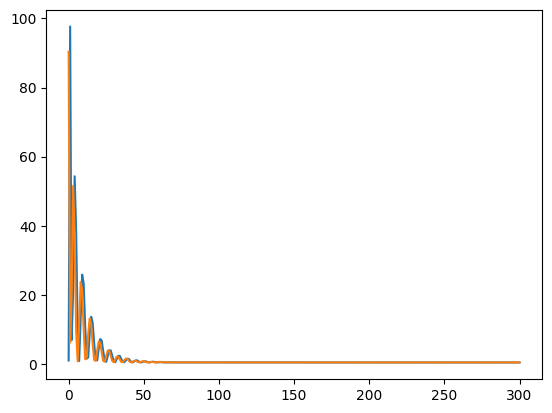

(-1.0, 1.0)

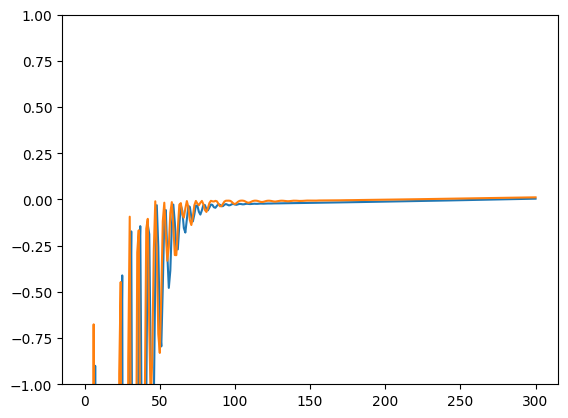

In [11]:
plt.plot(training_losses["train_loss"], label="Train Loss")
plt.plot(training_losses["val_loss"], label="Val Loss")
plt.show()

plt.plot(training_losses["train_r2"], label="Train R²")
plt.plot(training_losses["val_r2"], label="Val R²")
plt.ylim(-1,1)

#### Fazendo simultaneamente para um número diferente de neurônios da camada oculta, vizinhos que foram utilizados (quantos vizinhos mais próximos cada nó terá no grafo), e quantidade de camadas ocultas.

In [ ]:
import itertools
import pandas as pd

def run_experiment(epochs, hidden, X_in, y_all, A_norm,
                   mask_train, mask_val, mask_test,
                   F_in=2, lr=1e-3, n_idx=32, seed=42):
    # Re-seed a cada rodada para que cada combinação parta do mesmo ponto.
    # Sem isso, a ordem dos experimentos afetaria os resultados.
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    modelo = SimpleGNN(in_dim=F_in, hidden_dim=hidden)
    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoca in range(epochs + 1):
        modelo.train()
        otimizador.zero_grad()
        y_pred_all = modelo(X_in, A_norm)
        loss_train = loss_fn(y_pred_all[mask_train], y_all[mask_train])
        loss_train.backward()
        otimizador.step()

    # Avaliação final — calcula as três losses de uma vez
    modelo.eval()
    with torch.no_grad():
        y_pred_all = modelo(X_in, A_norm)
        loss_train_f = loss_fn(y_pred_all[mask_train], y_all[mask_train]).item()
        loss_val_f   = loss_fn(y_pred_all[mask_val],   y_all[mask_val]).item()
        loss_test_f  = loss_fn(y_pred_all[mask_test],  y_all[mask_test]).item()
        pred_no      = y_pred_all[n_idx].item()
        true_no      = y_all[n_idx].item()

    return {
        "epochs":     epochs,
        "hidden":     hidden,
        "loss_train": loss_train_f,
        "loss_val":   loss_val_f,
        "loss_test":  loss_test_f,
        "pred":       pred_no,
        "true":       true_no,
    }


# =====================================================
# Grid search
# =====================================================
epochs_grid = [100, 200]
hidden_grid = [2, 6, 12]

resultados = []
for ep, hd in itertools.product(epochs_grid, hidden_grid):
    print(f"Rodando epochs={ep}, hidden={hd}...")
    r = run_experiment(ep, hd, X_in, y_all, A_norm,
                       mask_train, mask_val, mask_test)
    resultados.append(r)

df = pd.DataFrame(resultados)
print(df)
df.to_csv("resultados_gnn.csv", index=False)

Rodando epochs=100, hidden=2...
Rodando epochs=100, hidden=6...
Rodando epochs=100, hidden=12...
Rodando epochs=200, hidden=2...
Rodando epochs=200, hidden=6...
Rodando epochs=200, hidden=12...
   epochs  hidden  loss_train  loss_val  loss_test      pred  true
0     100       2    0.442331  0.462037   0.851507  0.337538   0.0
1     100       6    0.485220  0.490312   0.923421  0.360447   0.0
2     100      12    0.461948  0.478640   0.886457  0.316273   0.0
3     200       2    0.442021  0.461358   0.850564  0.345904   0.0
4     200       6    0.484631  0.488185   0.921653  0.374483   0.0
5     200      12    0.460079  0.473851   0.882296  0.358198   0.0


Passagem de dataframe para LaTeX (tabelas do Overleaf)

In [13]:
latex = df.to_latex(
    index=False,
    float_format="%.3f",                # 3 casas decimais
    caption="Resultados experimentais da GNN para diferentes configurações de hiperparâmetros.",
    label="tab:gnn_results",
    column_format="rrrrrrr",            # 7 colunas: epochs, hidden, loss_train, loss_val, loss_test, pred, true
    position="h",
)
print(latex)

\begin{table}[h]
\caption{Resultados experimentais da GNN para diferentes configurações de hiperparâmetros.}
\label{tab:gnn_results}
\begin{tabular}{rrrrrrr}
\toprule
epochs & hidden & loss_train & loss_val & loss_test & pred & true \\
\midrule
100 & 2 & 0.442 & 0.462 & 0.852 & 0.338 & 0.000 \\
100 & 6 & 0.485 & 0.490 & 0.923 & 0.360 & 0.000 \\
100 & 12 & 0.462 & 0.479 & 0.886 & 0.316 & 0.000 \\
200 & 2 & 0.442 & 0.461 & 0.851 & 0.346 & 0.000 \\
200 & 6 & 0.485 & 0.488 & 0.922 & 0.374 & 0.000 \\
200 & 12 & 0.460 & 0.474 & 0.882 & 0.358 & 0.000 \\
\bottomrule
\end{tabular}
\end{table}



Nós

NameError: name 'build_adjacency' is not defined

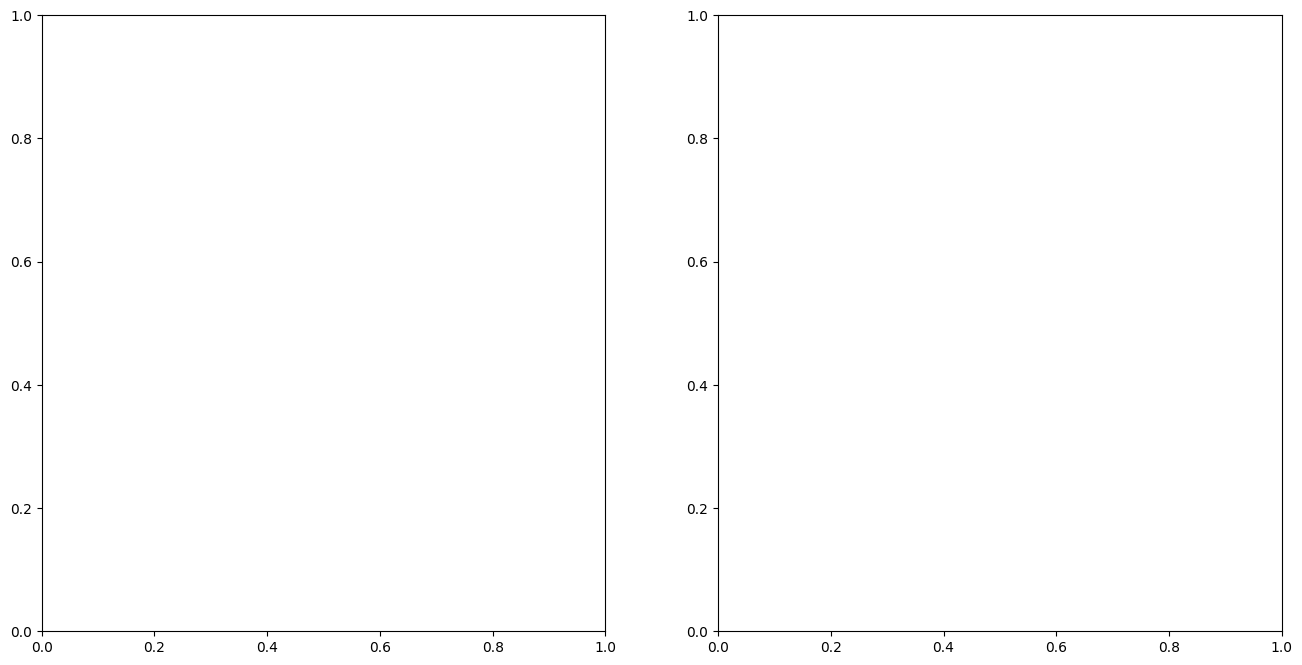

In [14]:
def plot_graph(ax, A_bin, coords, mask_train, mask_val, mask_test, n_idx, k):
    N = coords.shape[0]

    # ---- Arestas cinzas (estrutura geral do grafo) ----
    for i in range(N):
        for j in range(i + 1, N):
            if A_bin[i, j]:
                ax.plot(
                    [coords[i, 1], coords[j, 1]],
                    [coords[i, 0], coords[j, 0]],
                    color="gray", alpha=0.3, linewidth=0.6, zorder=1,
                )

    # ---- Nós, coloridos por conjunto ----
    ax.scatter(coords[mask_train.numpy(), 1], coords[mask_train.numpy(), 0],
               c="tab:blue", label="treino", s=50, alpha=0.8, zorder=2)
    ax.scatter(coords[mask_val.numpy(), 1], coords[mask_val.numpy(), 0],
               c="tab:orange", label="validação", s=50, alpha=0.8, zorder=2)
    ax.scatter(coords[mask_test.numpy(), 1], coords[mask_test.numpy(), 0],
               c="tab:red", label="teste", s=50, alpha=0.8, zorder=2)

    # ---- Apenas a estrela do nó de interesse, sem destacar arestas ----
    vizinhos = np.where(A_bin[n_idx] > 0)[0]
    ax.scatter(coords[n_idx, 1], coords[n_idx, 0],
               c="black", marker="*", s=300, label=f"nó {n_idx}", zorder=5)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"k = {k} ({len(vizinhos)} vizinhos diretos do nó {n_idx})")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9)

    # =====================================================
# Plota lado a lado para k=2 e k=3
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, k in zip(axes, [2, 3]):
    A_k = build_adjacency(coords, k)
    plot_graph(ax, A_k, coords, mask_train, mask_val, mask_test, n_idx, k)

    # Lista vizinhos do nó 32 para cada k
    vizinhos_k = np.where(A_k[n_idx] > 0)[0]
    print(f"\n--- k = {k} ---")
    print(f"Vizinhos diretos do nó {n_idx}:")
    for j in vizinhos_k:
        if mask_train[j]:    conj = "treino"
        elif mask_val[j]:    conj = "validação"
        else:                conj = "teste"
        print(f"  nó {j:3d} -> {conj}")

plt.suptitle(f"Grafo k-NN das estações para diferentes valores de k", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
modelo.eval()
with torch.no_grad():
    y_pred_all = modelo(X_in, A_norm)

    # Erro quadrático elemento a elemento (sem média)
    erro_sq = (y_pred_all - y_all) ** 2          # shape (N,)
    erro_abs = (y_pred_all - y_all).abs()        # shape (N,)

# Filtra só os nós de teste
idx_teste = torch.where(mask_test)[0]

df_teste = pd.DataFrame({
    "no":      idx_teste.numpy(),
    "y_real":  y_all[mask_test].numpy(),
    "y_pred":  y_pred_all[mask_test].numpy(),
    "erro":    (y_pred_all[mask_test] - y_all[mask_test]).numpy(),
    "erro_abs": erro_abs[mask_test].numpy(),
    "loss_no": erro_sq[mask_test].numpy(),       # contribuição individual ao MSE
})

# Ordena do maior para o menor erro — os "casos difíceis" primeiro
df_teste = df_teste.sort_values("loss_no", ascending=False).reset_index(drop=True)

print(df_teste.round(4).to_string(index=False))

# Sanidade: a média da coluna loss_no deve bater com loss_test_f do seu código
print(f"\nMédia das losses individuais: {df_teste['loss_no'].mean():.4f}")
print(f"Loss de teste (agregada):     {erro_sq[mask_test].mean().item():.4f}")

 no  y_real  y_pred    erro  erro_abs  loss_no
  8  3.1824  0.3602 -2.8222    2.8222   7.9647
 43  0.0000  0.3727  0.3727    0.3727   0.1389
 32  0.0000  0.3683  0.3683    0.3683   0.1356
  5  0.0000  0.3664  0.3664    0.3664   0.1342
 26  0.0038  0.3652  0.3614    0.3614   0.1306
 13  0.0539  0.3606  0.3067    0.3067   0.0941
 35  0.0639  0.3680  0.3041    0.3041   0.0925
 36  0.0911  0.3637  0.2726    0.2726   0.0743
 52  0.2828  0.3673  0.0846    0.0846   0.0072
 25  0.4368  0.3669 -0.0699    0.0699   0.0049

Média das losses individuais: 0.8777
Loss de teste (agregada):     0.8777
